# Customer Analytics — Level 7: Business Recommendation Engine

This notebook serves as the final stage of the Customer Analytics project by translating analytical findings into practical business recommendations.

Rather than introducing new analytical techniques, this section consolidates insights from the previous six notebooks and converts them into actionable strategies that support customer retention, revenue growth, and long-term business performance.

The recommendation framework combines findings from:

- Executive Business Metrics
- Customer Acquisition Analysis
- Customer Retention Analysis
- Customer Lifetime Value (CLV)
- RFM Customer Segmentation
- Customer Behavior Analysis

The objective is to bridge the gap between data analysis and business decision-making by providing recommendations that can be directly applied to marketing, customer relationship management, and growth initiatives.

**Data Sources**

- `online_retail_clean.csv`
- `rfm_segments.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

np.random.seed(42)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns',None)

df = pd.read_csv("data/raw/online_retail_clean.csv", parse_dates=["InvoiceDate"])
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
rfm = pd.read_csv("data/raw/rfm_segments.csv")

print(f"Total customers: {df['CustomerID'].nunique():,} | Total revenue: £{df['Revenue'].sum():,.0f}")

Total customers: 4,338 | Total revenue: £8,911,408


## 1. Generating Executive Insight Metrics

The executive insight cards presented in this notebook are calculated directly from the underlying transaction data rather than using manually entered values.

This ensures that every business recommendation remains fully consistent with the analytical results and automatically updates whenever the dataset changes.

In [2]:
# --- Insight A: Champions concentration ---
seg_summary = rfm.groupby("Segment").agg(Customers=("CustomerID","count"), Revenue=("Monetary","sum")).reset_index()
total_cust, total_rev = seg_summary["Customers"].sum(), seg_summary["Revenue"].sum()
champions = seg_summary[seg_summary["Segment"]=="Champions"].iloc[0]
champions_cust_pct = champions["Customers"]/total_cust*100
champions_rev_pct = champions["Revenue"]/total_rev*100

# --- Insight B: Retention stability (MoM retention, awal vs akhir periode) ---
first_purchase = df.groupby("CustomerID")["InvoiceMonth"].min().reset_index()
first_purchase.columns = ["CustomerID","CohortMonth"]
active_per_month = df.groupby("InvoiceMonth")["CustomerID"].agg(set).reset_index()
active_per_month.columns = ["Month","Active"]
months = active_per_month["Month"].tolist()
retentions = []
for i in range(1, len(months)):
    prev = active_per_month.loc[active_per_month["Month"]==months[i-1],"Active"].values[0]
    now = active_per_month.loc[active_per_month["Month"]==months[i],"Active"].values[0]
    retentions.append(len(prev & now)/len(prev)*100 if len(prev)>0 else np.nan)
ret_series = pd.Series(retentions)
retention_early = ret_series.iloc[:len(ret_series)//2].mean()
retention_late = ret_series.iloc[len(ret_series)//2:].mean()

# --- Insight C: CLV by cohort (apples-to-apples, revenue for the first 3 months since acquisition) ---
df2 = df.merge(first_purchase, on="CustomerID")
def month_diff(later, earlier):
    return (later.year-earlier.year)*12 + (later.month-earlier.month)
df2["CohortIndex"] = df2.apply(lambda r: month_diff(r["InvoiceMonth"], r["CohortMonth"]), axis=1)
clv_3mo = df2[df2["CohortIndex"]<=2].groupby("CohortMonth").apply(
    lambda g: g["Revenue"].sum()/g["CustomerID"].nunique()).reset_index(name="CLV_3mo")
clv_3mo["CohortMonth"] = clv_3mo["CohortMonth"].astype(str)
first_cohort_clv = clv_3mo.iloc[0]["CLV_3mo"]
# compare with the cohort that has a full 3-month window (up to Sep 2011, because the data ends on Dec 9, 2011)
fair_cohorts = clv_3mo[clv_3mo["CohortMonth"] <= "2011-09"]
later_avg_clv = fair_cohorts.iloc[1:]["CLV_3mo"].mean()
clv_decline_pct = (later_avg_clv - first_cohort_clv) / first_cohort_clv * 100

# --- Insight D: At Risk + Lost = what % of customers, what % of revenue ---
at_risk_lost = seg_summary[seg_summary["Segment"].isin(["At Risk","Lost Customers"])]
ar_lost_cust_pct = at_risk_lost["Customers"].sum()/total_cust*100
ar_lost_rev_pct = at_risk_lost["Revenue"].sum()/total_rev*100

print(f"A. Champions                   : {champions_cust_pct:.1f}% customer -> {champions_rev_pct:.1f}% revenue")
print(f"B. Retention (MoM)             : {retention_early:.1f}% (beginning of the period) -> {retention_late:.1f}% (end of period)")
print(f"C. Early CLV cohort vs average : £{first_cohort_clv:,.0f} -> £{later_avg_clv:,.0f}  ({clv_decline_pct:.1f}%)")
print(f"D. At Risk + Lost              : {ar_lost_cust_pct:.1f}% customer, hanya {ar_lost_rev_pct:.1f}% revenue")

A. Champions                   : 22.2% customer -> 65.2% revenue
B. Retention (MoM)             : 37.2% (beginning of the period) -> 38.3% (end of period)
C. Early CLV cohort vs average : £1,223 -> £684  (-44.1%)
D. At Risk + Lost              : 43.3% customer, hanya 15.0% revenue


## 2. Executive Insight Cards

The following insight cards summarize the most important business findings identified throughout the Customer Analytics project.

Each metric is derived directly from the analytical workflow, allowing decision-makers to quickly understand customer acquisition quality, retention performance, revenue concentration, and overall customer value without reviewing every individual analysis.

> **Methodological Note**
>
> Customer Lifetime Value comparisons between acquisition cohorts use an identical observation window (the first three months after acquisition). This standardized approach ensures fair comparisons across cohorts regardless of when customers entered the business.

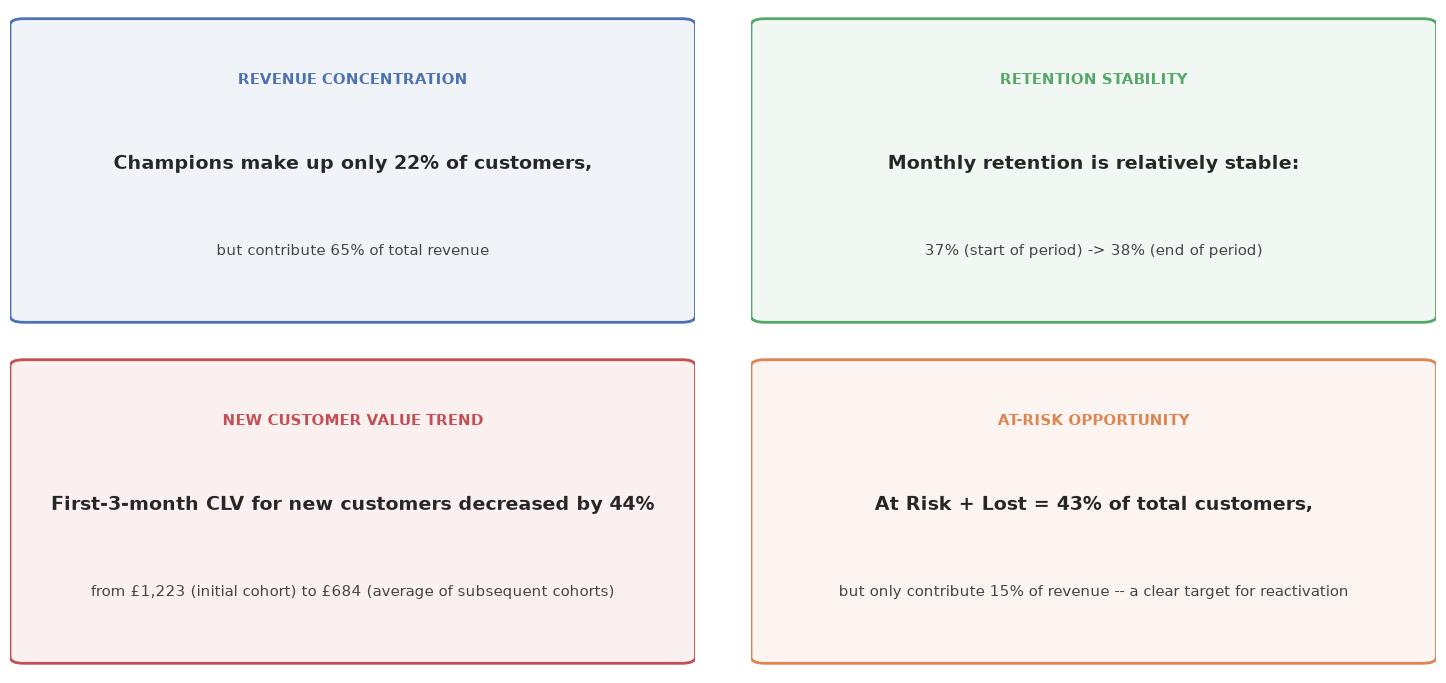

In [3]:
cards = [
    {
        "title": "Revenue Concentration",
        "headline": f"Champions make up only {champions_cust_pct:.0f}% of customers,",
        "sub": f"but contribute {champions_rev_pct:.0f}% of total revenue",
        "color": "#4C72B0"
    },
    {
        "title": "Retention Stability",
        "headline": "Monthly retention is relatively stable:",
        "sub": f"{retention_early:.0f}% (start of period) -> {retention_late:.0f}% (end of period)",
        "color": "#55A868"
    },
    {
        "title": "New Customer Value Trend",
        "headline": f"First-3-month CLV for new customers decreased by {abs(clv_decline_pct):.0f}%",
        "sub": f"from £{first_cohort_clv:,.0f} (initial cohort) to £{later_avg_clv:,.0f} (average of subsequent cohorts)",
        "color": "#C44E52"
    },
    {
        "title": "At-Risk Opportunity",
        "headline": f"At Risk + Lost = {ar_lost_cust_pct:.0f}% of total customers,",
        "sub": f"but only contribute {ar_lost_rev_pct:.0f}% of revenue -- a clear target for reactivation",
        "color": "#DD8452"
    }
]

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
axes = axes.flatten()
for ax, card in zip(axes, cards):
    ax.axis("off")
    rect = patches.FancyBboxPatch((0.02,0.05), 0.96, 0.9, boxstyle="round,pad=0.02",
                                    linewidth=2, edgecolor=card["color"], facecolor=card["color"]+"15")
    ax.add_patch(rect)
    ax.text(0.5, 0.78, card["title"].upper(), ha="center", va="center", fontsize=11,
            fontweight="bold", color=card["color"])
    ax.text(0.5, 0.52, card["headline"], ha="center", va="center", fontsize=13.5, fontweight="bold", wrap=True)
    ax.text(0.5, 0.25, card["sub"], ha="center", va="center", fontsize=10.5, color="#444444", wrap=True)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.tight_layout()
plt.savefig("pictures/level7_insight_cards.png", dpi=120, bbox_inches='tight')
plt.show()

## 3. Segment-Specific Business Recommendations

Customer segmentation becomes valuable only when it leads to actionable decisions.

Using the RFM segments developed in Level 5, each customer group is matched with a recommended business strategy based on its behavioral characteristics and economic value.

Rather than applying a single marketing approach to every customer, businesses can prioritize retention, reactivation, loyalty, or acquisition initiatives according to the specific needs of each segment.

In [4]:
recommendations = pd.DataFrame([
    {"Segment": "Champions", "Customers": int(seg_summary.set_index('Segment').loc['Champions','Customers']),
     "RevenueShare%": round(champions_rev_pct,1),
     "Recommended Action": "Loyalty Program / VIP perks",
     "Rationale": "Already the most valuable -- retain them with exclusive rewards, early access to new products, and dedicated support."},
    {"Segment": "Loyal Customers", "Customers": int(seg_summary.set_index('Segment').loc['Loyal Customers','Customers']),
     "RevenueShare%": round(seg_summary.set_index('Segment').loc['Loyal Customers','Revenue']/total_rev*100,1),
     "Recommended Action": "Cross-sell & Referral Program",
     "Rationale": "Frequent buyers but monetary value is not yet top-tier -- encourage larger basket sizes and leverage for referrals."},
    {"Segment": "Potential Loyalists", "Customers": int(seg_summary.set_index('Segment').loc['Potential Loyalists','Customers']),
     "RevenueShare%": round(seg_summary.set_index('Segment').loc['Potential Loyalists','Revenue']/total_rev*100,1),
     "Recommended Action": "Upselling & Personalized Offer",
     "Rationale": "Starting to buy more frequently -- great momentum to upgrade them into Loyal/Champion status."},
    {"Segment": "New Customers", "Customers": int(seg_summary.set_index('Segment').loc['New Customers','Customers']),
     "RevenueShare%": round(seg_summary.set_index('Segment').loc['New Customers','Revenue']/total_rev*100,1),
     "Recommended Action": "Onboarding Series / Welcome Discount",
     "Rationale": "First-time buyers -- a good onboarding experience determines whether they become repeat buyers."},
    {"Segment": "At Risk", "Customers": int(seg_summary.set_index('Segment').loc['At Risk','Customers']),
     "RevenueShare%": round(seg_summary.set_index('Segment').loc['At Risk','Revenue']/total_rev*100,1),
     "Recommended Action": "Reactivation Campaign",
     "Rationale": "Previously active, but recency is dropping -- use email/promo reminders before they grow colder."},
    {"Segment": "Cant Lose Them", "Customers": int(seg_summary.set_index('Segment').loc['Cant Lose Them','Customers']),
     "RevenueShare%": round(seg_summary.set_index('Segment').loc['Cant Lose Them','Revenue']/total_rev*100,1),
     "Recommended Action": "Personal Outreach / High-touch Win-back",
     "Rationale": "Previously highly valuable but haven't purchased in a while -- worth the extra effort (personal phone calls/emails), high risk of revenue loss."},
    {"Segment": "Lost Customers", "Customers": int(seg_summary.set_index('Segment').loc['Lost Customers','Customers']),
     "RevenueShare%": round(seg_summary.set_index('Segment').loc['Lost Customers','Revenue']/total_rev*100,1),
     "Recommended Action": "Win-back Campaign (low-cost)",
     "Rationale": "Haven't purchased for a long time, low frequency -- run broad/low-cost campaigns (deep discounts, churn reason surveys)."},
])
recommendations

,Segment,Customers,RevenueShare%,Recommended Action,Rationale
0,Champions,962,65.20,Loyalty Program / VIP perks,Already the most valuable -- retain them with ...
1,Loyal Customers,498,10.00,Cross-sell & Referral Program,Frequent buyers but monetary value is not yet ...
2,Potential Loyalists,492,5.70,Upselling & Personalized Offer,Starting to buy more frequently -- great momen...
3,New Customers,141,0.60,Onboarding Series / Welcome Discount,First-time buyers -- a good onboarding experie...
4,At Risk,1017,10.40,Reactivation Campaign,"Previously active, but recency is dropping -- ..."
5,Cant Lose Them,201,2.70,Personal Outreach / High-touch Win-back,Previously highly valuable but haven't purchas...
6,Lost Customers,863,4.60,Win-back Campaign (low-cost),"Haven't purchased for a long time, low frequen..."


### Comparing Customer Share and Revenue Contribution

The visualization below compares the proportion of customers in each segment with the revenue generated by that segment.

This comparison highlights whether business value is broadly distributed across the customer base or concentrated within a relatively small group of customers, providing an evidence-based foundation for strategic prioritization.

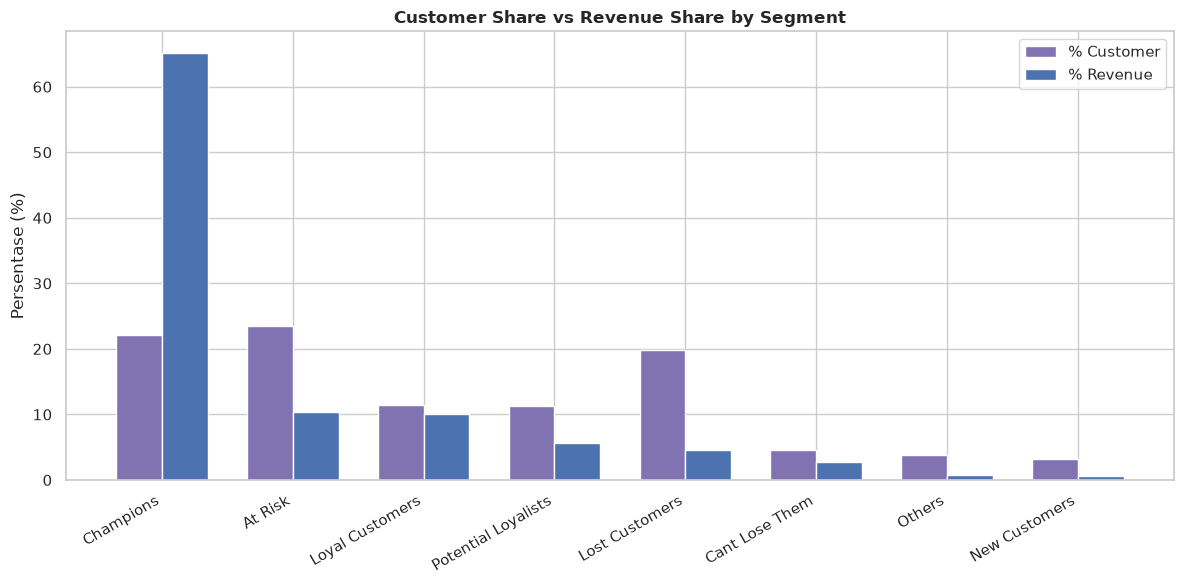

In [5]:
seg_summary["CustPct"] = seg_summary["Customers"]/total_cust*100
seg_summary["RevPct"] = seg_summary["Revenue"]/total_rev*100
seg_summary_sorted = seg_summary.sort_values("RevPct", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(seg_summary_sorted))
width = 0.35
ax.bar(x - width/2, seg_summary_sorted["CustPct"], width, label="% Customer", color="#8172B2")
ax.bar(x + width/2, seg_summary_sorted["RevPct"], width, label="% Revenue", color="#4C72B0")
ax.set_xticks(x)
ax.set_xticklabels(seg_summary_sorted["Segment"], rotation=30, ha='right')
ax.set_ylabel("Persentase (%)")
ax.set_title("Customer Share vs Revenue Share by Segment")
ax.legend()
plt.tight_layout()
plt.savefig("pictures/level7_segment_priority.png", dpi=120, bbox_inches='tight')
plt.show()

In [7]:
import os

os.makedirs("data/processed", exist_ok=True)

recommendations.to_csv("data/processed/business_recommendations.csv", index=False)

## 4. Executive Summary

### Customer Analytics: Acquisition, Retention, and Lifetime Value Analysis

This project analyzed customer transactions from the Online Retail dataset through a complete end-to-end customer analytics framework.

Across seven analytical stages, the project examined customer acquisition, retention, lifetime value, behavioral patterns, and segmentation to build a comprehensive understanding of customer performance.

The analyses reveal several consistent business themes:

- Customer value is unevenly distributed, with a relatively small segment of customers contributing a disproportionately large share of business revenue.
- Customer retention remains a critical driver of long-term business performance, as repeat customers generate substantially more value than one-time purchasers.
- Customer behavior varies considerably across segments, indicating that different customer groups require different engagement strategies rather than a single marketing approach.
- Combining CLV, RFM segmentation, and behavioral analytics provides a significantly richer understanding of customers than relying solely on aggregate business metrics.

The final recommendation engine translates these analytical findings into actionable business strategies, demonstrating how customer analytics can directly support marketing prioritization, customer relationship management, and revenue growth initiatives.

### Project Limitations

Several limitations should be considered when interpreting the results:

- Profit values are estimated using simulated margin assumptions because the original dataset does not include product cost information.
- The dataset primarily represents wholesale purchasing behavior, meaning customer patterns may differ from those observed in a typical B2C e-commerce business.
- More recent acquisition cohorts have shorter observation periods, which naturally limits long-term retention and lifetime value comparisons.

Despite these limitations, the analytical framework remains broadly applicable and can be adapted to other transactional datasets with minimal modification.